In [1]:
import scanpy as sc

adata = sc.read_h5ad("adata_normalized.h5ad")

print(adata)

print("\nOBS:")
print(adata.obs.columns.tolist())

print("\nVAR:")
print(adata.var.columns.tolist())

print("\nLAYERS:")
print(list(adata.layers.keys()))

print("\nUNS:")
print(list(adata.uns.keys()))

print("\nOBSM:")
print(list(adata.obsm.keys()))

print("\nRAW:")
print(adata.raw)

AnnData object with n_obs × n_vars = 24073 × 16432
    obs: 'bc_wells', 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_id', 'gene_name', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'mean', 'std'
    uns: 'log1p'

OBS:
['bc_wells', 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',

In [2]:
adata_initial = sc.read_h5ad("MB231_initial_50k.h5ad")

print(adata_initial)

print("\nLAYERS:")
print(list(adata_initial.layers.keys()))

print("\nRAW:")
print(adata_initial.raw)

print("\nFirst values in X:")
print(
    adata_initial.X[:5, :5].toarray()
    if hasattr(adata_initial.X, "toarray")
    else adata_initial.X[:5, :5]
)

AnnData object with n_obs × n_vars = 50000 × 63142
    obs: 'bc_wells', 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well'

LAYERS:
[]

RAW:
None

First values in X:
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 2 0]
 [0 0 0 0 0]]


In [3]:
print("Normalized cells:", adata.n_obs)
print("Raw cells:", adata_initial.n_obs)

shared_cells = adata.obs_names.intersection(adata_initial.obs_names)

print("Shared cells:", len(shared_cells))
print("First IDs:", shared_cells[:5].tolist())


Normalized cells: 24073
Raw cells: 50000
Shared cells: 24073
First IDs: ['2190793', '1825781', '342687', '1096902', '356848']


In [4]:
print("Raw genes:", adata_initial.n_vars)
print("Normalized genes:", adata.n_vars)

print("\nRaw var names:")
print(adata_initial.var_names[:10].tolist())

print("\nNormalized var names:")
print(adata.var_names[:10].tolist())

print("\nRaw var columns:")
print(adata_initial.var.columns.tolist())

print("\nNormalized var columns:")
print(adata.var.columns.tolist())

Raw genes: 63142
Normalized genes: 16432

Raw var names:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Normalized var names:
['EGFP', 'TSPAN6', 'DPM1', 'SCYL3', 'FIRRM', 'CFH', 'FUCA2', 'GCLC', 'NFYA', 'STPG1']

Raw var columns:
[]

Normalized var columns:
['gene_id', 'gene_name', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'mean', 'std']


In [5]:
import pandas as pd

genes = pd.read_csv("GSM8721081_all_genes.csv")

print(genes.shape)
print(genes.columns.tolist())
print(genes.head(10))

(63142, 3)
['gene_id', 'gene_name', 'genome']
           gene_id gene_name genome
0             EGFP      EGFP   hg38
1  ENSG00000000003    TSPAN6   hg38
2  ENSG00000000005      TNMD   hg38
3  ENSG00000000419      DPM1   hg38
4  ENSG00000000457     SCYL3   hg38
5  ENSG00000000460     FIRRM   hg38
6  ENSG00000000938       FGR   hg38
7  ENSG00000000971       CFH   hg38
8  ENSG00000001036     FUCA2   hg38
9  ENSG00000001084      GCLC   hg38


In [6]:
# Add gene annotation to the raw AnnData object
adata_initial.var = genes.copy()
adata_initial.var_names = genes["gene_name"].astype(str)

# Check for duplicated gene names
print("Total genes:", adata_initial.n_vars)
print("Unique gene names:", adata_initial.var_names.nunique())
print("Duplicated gene names:", adata_initial.var_names.duplicated().sum())

print("\nFirst genes:")
print(adata_initial.var_names[:10].tolist())

Total genes: 63142
Unique gene names: 61512
Duplicated gene names: 1630

First genes:
['EGFP', 'TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'FIRRM', 'FGR', 'CFH', 'FUCA2', 'GCLC']


/Users/serafimaabakumova/miniforge3/envs/scrna/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [7]:
print("Total gene IDs:", len(genes))
print("Unique gene IDs:", genes["gene_id"].nunique())
print("Duplicated gene IDs:", genes["gene_id"].duplicated().sum())

print("\nNormalized gene IDs:")
print("Total:", adata.n_vars)
print("Unique:", adata.var["gene_id"].nunique())
print("Duplicated:", adata.var["gene_id"].duplicated().sum())

Total gene IDs: 63142
Unique gene IDs: 63142
Duplicated gene IDs: 0

Normalized gene IDs:
Total: 16432
Unique: 16432
Duplicated: 0


In [8]:
raw_gene_ids = set(adata_initial.var["gene_id"])
normalized_gene_ids = set(adata.var["gene_id"])

shared_gene_ids = normalized_gene_ids.intersection(raw_gene_ids)

print("Normalized genes:", len(normalized_gene_ids))
print("Found in raw:", len(shared_gene_ids))
print("Missing from raw:", len(normalized_gene_ids - raw_gene_ids))

Normalized genes: 16432
Found in raw: 16432
Missing from raw: 0


In [9]:
# Use gene_id as the unique identifier in the raw object
adata_initial.var_names = adata_initial.var["gene_id"].astype(str)

# Select exactly the QC-passed cells and filtered genes
adata_raw_filtered = adata_initial[
    adata.obs_names,
    adata.var["gene_id"].astype(str)
].copy()

# Replace gene IDs with gene symbols for convenient downstream analysis
adata_raw_filtered.var["gene_id"] = adata_raw_filtered.var_names.copy()
adata_raw_filtered.var_names = adata.var_names.copy()

print(adata_raw_filtered)
print("\nShape:", adata_raw_filtered.shape)

print("\nFirst values:")
print(
    adata_raw_filtered.X[:5, :5].toarray()
    if hasattr(adata_raw_filtered.X, "toarray")
    else adata_raw_filtered.X[:5, :5]
)

AnnData object with n_obs × n_vars = 24073 × 16432
    obs: 'bc_wells', 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well'
    var: 'gene_id', 'gene_name', 'genome'

Shape: (24073, 16432)

First values:
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


In [11]:
import pandas as pd

expression_df = pd.DataFrame(
    adata.X,
    index=adata.obs_names,
    columns=adata.var_names
)

print(expression_df.shape)
print(expression_df.iloc[:5, :5])

(24073, 16432)
             EGFP   TSPAN6      DPM1     SCYL3     FIRRM
2190793 -0.042301 -0.03159 -0.072777 -0.047852 -0.090795
1825781 -0.042301 -0.03159 -0.072777 -0.047852 -0.090795
342687  -0.042301 -0.03159 -0.072777 -0.047852 -0.090795
1096902 -0.042301 -0.03159 -0.072777 -0.047852 -0.090795
356848  -0.042301 -0.03159 -0.072777 -0.047852 -0.090795


In [12]:
# Create a separate AnnData object for regulatory analysis
adata_scenic = adata_raw_filtered.copy()

# Reproduce the original normalization
sc.pp.normalize_total(adata_scenic, target_sum=1e4)

# Reproduce the original log transformation
sc.pp.log1p(adata_scenic)

print(adata_scenic.shape)
print("Min:", adata_scenic.X.min())
print("Max:", adata_scenic.X.max())

print(
    adata_scenic.X[:5, :5].toarray()
    if hasattr(adata_scenic.X, "toarray")
    else adata_scenic.X[:5, :5]
)

(24073, 16432)
Min: 0.0
Max: 7.389346
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [13]:
with open("lambert2018.txt", "r") as f:
    tf_list = [line.strip() for line in f if line.strip()]

tf_in_data = [tf for tf in tf_list if tf in adata_scenic.var_names]

print("TFs in Lambert list:", len(tf_list))
print("TFs found in our dataset:", len(tf_in_data))
print("First 20 TFs found:")
print(tf_in_data[:20])

TFs in Lambert list: 1639
TFs found in our dataset: 1150
First 20 TFs found:
['TFAP2A', 'TFAP2C', 'TFAP2E', 'ARID3A', 'ARID3B', 'ARID5A', 'ARID5B', 'KDM5B', 'ARID2', 'AHCTF1', 'AHDC1', 'AKNA', 'ASH1L', 'CBX2', 'DNTTIP1', 'DOT1L', 'GLYR1', 'HMGA1', 'HMGA2', 'PHF20']


In [14]:
adata_scenic.write_h5ad("MB231_scenic_input.h5ad")

print("Saved:", adata_scenic.shape)

Saved: (24073, 16432)


In [15]:
print(hasattr(adata_scenic, "write_loom"))

True


In [17]:
adata_scenic.write_loom("MB231_scenic_input.loom")

print("Loom saved")

Loom saved


In [18]:
import numpy as np

n_cells_expressed = np.asarray((adata_raw_filtered.X > 0).sum(axis=0)).ravel()

for pct in [0.001, 0.005, 0.01, 0.02, 0.05]:
    threshold = int(adata_raw_filtered.n_obs * pct)
    n_genes = (n_cells_expressed >= threshold).sum()
    print(
        f"{pct*100:.1f}% cells ({threshold} cells): "
        f"{n_genes} genes retained"
    )

0.1% cells (24 cells): 9921 genes retained
0.5% cells (120 cells): 4121 genes retained
1.0% cells (240 cells): 2059 genes retained
2.0% cells (481 cells): 693 genes retained
5.0% cells (1203 cells): 97 genes retained


In [19]:
min_cells = 24

keep_genes = (n_cells_expressed >= min_cells) | adata_raw_filtered.var_names.isin(tf_in_data)

adata_scenic_filtered = adata_scenic[:, keep_genes].copy()

print("Before:", adata_scenic.shape)
print("After:", adata_scenic_filtered.shape)

tf_after = set(tf_in_data) & set(adata_scenic_filtered.var_names)
print("TFs retained:", len(tf_after))

Before: (24073, 16432)
After: (24073, 10311)
TFs retained: 1150


In [20]:
adata_scenic_filtered.write_loom("MB231_scenic_filtered.loom")

print("Saved:", adata_scenic_filtered.shape)

Saved: (24073, 10311)


In [ ]:
import numpy as np

n_cells_expressed = np.asarray((adata_raw_filtered.X > 0).sum(axis=0)).ravel()

for pct in [0.001, 0.005, 0.01, 0.02, 0.05]:
    threshold = int(adata_raw_filtered.n_obs * pct)
    n_genes = (n_cells_expressed >= threshold).sum()
    print(
        f"{pct*100:.1f}% cells ({threshold} cells): "
        f"{n_genes} genes retained"
    )

0.1% cells (24 cells): 9921 genes retained
0.5% cells (120 cells): 4121 genes retained
1.0% cells (240 cells): 2059 genes retained
2.0% cells (481 cells): 693 genes retained
5.0% cells (1203 cells): 97 genes retained


In [ ]:
import numpy as np

n_cells_expressed = np.asarray((adata_raw_filtered.X > 0).sum(axis=0)).ravel()

for pct in [0.001, 0.005, 0.01, 0.02, 0.05]:
    threshold = int(adata_raw_filtered.n_obs * pct)
    n_genes = (n_cells_expressed >= threshold).sum()
    print(
        f"{pct*100:.1f}% cells ({threshold} cells): "
        f"{n_genes} genes retained"
    )

0.1% cells (24 cells): 9921 genes retained
0.5% cells (120 cells): 4121 genes retained
1.0% cells (240 cells): 2059 genes retained
2.0% cells (481 cells): 693 genes retained
5.0% cells (1203 cells): 97 genes retained


In [ ]:
import numpy as np

n_cells_expressed = np.asarray((adata_raw_filtered.X > 0).sum(axis=0)).ravel()

for pct in [0.001, 0.005, 0.01, 0.02, 0.05]:
    threshold = int(adata_raw_filtered.n_obs * pct)
    n_genes = (n_cells_expressed >= threshold).sum()
    print(
        f"{pct*100:.1f}% cells ({threshold} cells): "
        f"{n_genes} genes retained"
    )

0.1% cells (24 cells): 9921 genes retained
0.5% cells (120 cells): 4121 genes retained
1.0% cells (240 cells): 2059 genes retained
2.0% cells (481 cells): 693 genes retained
5.0% cells (1203 cells): 97 genes retained


In [21]:
suffix_genes = [
    g for g in adata_scenic_filtered.var_names
    if g.rsplit("-", 1)[-1].isdigit()
]

print("Genes with numeric suffix:", len(suffix_genes))
print(suffix_genes[:30])

Genes with numeric suffix: 48
['H1-3', 'H1-1', 'NKX3-1', 'H1-4', 'H1-5', 'H1-2', 'H1-0', 'ERVK13-1', 'BMS1P4-1', 'MATR3-1', 'ZNF724-1', 'PDE8B-1', 'HERC2P3-1', 'SUGT1P3-1', 'STAG3L5P-1', 'POLR2J4-1', 'MFSD14CP-1', 'CROCCP3-1', 'CCT6P3-1', 'LINC01145-1', 'PGM5P2-1', 'UBE2Q2P2-1', 'RRP7BP-1', 'BMS1P1-1', 'CCDC144NL-1', 'ZNF252P-1', 'ALOX12P2-1', 'CRYBB2P1-1', 'SDHAP4-1', 'SVIL-AS1-1']


In [22]:
changed_names = adata_scenic_filtered.var_names != adata_scenic_filtered.var["gene_name"]

print("Names changed by make_unique:", changed_names.sum())

adata_scenic_filtered.var.loc[
    changed_names, ["gene_name"]
].head(30)

Names changed by make_unique: 40


,gene_name
BMS1P4-1,BMS1P4
MATR3-1,MATR3
ZNF724-1,ZNF724
PDE8B-1,PDE8B
HERC2P3-1,HERC2P3
SUGT1P3-1,SUGT1P3
STAG3L5P-1,STAG3L5P
POLR2J4-1,POLR2J4
MFSD14CP-1,MFSD14CP
CROCCP3-1,CROCCP3


In [23]:
changed_tf = [
    g for g in adata_scenic_filtered.var_names[changed_names]
    if g in tf_in_data
]

print("Changed TFs:", len(changed_tf))
print(changed_tf)

Changed TFs: 0
[]


In [25]:
import scanpy as sc
import pandas as pd

adata = sc.read_h5ad("adata_normalized.h5ad")
auc = pd.read_csv("MB231_auc_mtx.csv", index_col=0)

print("AnnData:", adata.shape)
print("AUCell:", auc.shape)
print("Same cells:", adata.obs_names.equals(auc.index))
print("Same cell set:", set(adata.obs_names) == set(auc.index))

AnnData: (24073, 16432)
AUCell: (24073, 225)
Same cells: False
Same cell set: False


In [26]:
print("AnnData IDs:")
print(adata.obs_names[:10].tolist())

print("\nAUCell IDs:")
print(auc.index[:10].tolist())

print("\nOverlap:", len(set(adata.obs_names) & set(auc.index)))

AnnData IDs:
['2190793', '1825781', '342687', '1096902', '356848', '1100802', '352089', '358857', '728196', '726548']

AUCell IDs:
[2190793, 1825781, 342687, 1096902, 356848, 1100802, 352089, 358857, 728196, 726548]

Overlap: 0


In [27]:
auc.index = auc.index.astype(str)

print("Same cells:", adata.obs_names.equals(auc.index))
print("Same cell set:", set(adata.obs_names) == set(auc.index))
print("Overlap:", len(set(adata.obs_names) & set(auc.index)))

Same cells: True
Same cell set: True
Overlap: 24073


In [28]:
import anndata as ad

adata_reg = ad.AnnData(
    X=auc.values,
    obs=adata.obs.copy()
)

adata_reg.obs_names = auc.index.copy()
adata_reg.var_names = auc.columns.copy()

print(adata_reg)

AnnData object with n_obs × n_vars = 24073 × 225
    obs: 'bc_wells', 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'


In [29]:
regulon_table = pd.DataFrame(
    adata_reg.X,
    index=adata_reg.obs_names,
    columns=adata_reg.var_names
)

regulon_table.head(10)

,AR(+),ARID3A(+),ATF3(+),BACH2(+),BCL11A(+),BCL6(+),BHLHE40(+),BHLHE41(+),CEBPB(+),CEBPG(+),...,ZNF790(+),ZNF799(+),ZNF813(+),ZNF821(+),ZNF829(+),ZNF845(+),ZNF860(+),ZSCAN20(+),ZSCAN29(+),ZSCAN9(+)
Cell,,,,,,,,,,,,,,,,,,,,,
2190793,0.097222,0.024310,0.009814,0.0,0.0,0.038867,0.035853,0.021189,0.018830,0.056848,...,0.0,0.024640,0.008915,0.106942,0.0,0.067829,0.010336,0.027253,0.0,0.0
1825781,0.113049,0.030226,0.011875,0.0,0.0,0.044035,0.053725,0.025366,0.035538,0.069767,...,0.0,0.035161,0.013663,0.124031,0.0,0.090655,0.015612,0.033309,0.0,0.0
342687,0.116602,0.031994,0.012288,0.0,0.0,0.045327,0.059432,0.026314,0.023570,0.072351,...,0.0,0.067368,0.015019,0.128083,0.0,0.098837,0.017119,0.034520,0.0,0.0
1096902,0.097222,0.024208,0.009814,0.0,0.0,0.038867,0.035853,0.021146,0.018804,0.056848,...,0.0,0.024456,0.008818,0.106942,0.0,0.067614,0.060185,0.027253,0.0,0.0
356848,0.116279,0.031484,0.012246,0.0,0.0,0.045112,0.057386,0.026184,0.023334,0.072093,...,0.0,0.037560,0.014535,0.127555,0.0,0.096253,0.016581,0.034399,0.0,0.0
1100802,0.114987,0.031144,0.012123,0.0,0.0,0.044789,0.056417,0.025969,0.023099,0.071447,...,0.0,0.037006,0.014341,0.126498,0.0,0.094961,0.016365,0.034157,0.0,0.0
352089,0.097868,0.039202,0.009937,0.0,0.0,0.038975,0.036929,0.021404,0.031008,0.057752,...,0.0,0.025471,0.009399,0.107470,0.0,0.173342,0.010874,0.027616,0.0,0.0
358857,0.111111,0.029410,0.011628,0.0,0.0,0.043497,0.050818,0.024892,0.035015,0.068088,...,0.0,0.033407,0.013081,0.122093,0.0,0.086563,0.014966,0.032582,0.0,0.0
728196,0.099483,0.025160,0.010185,0.0,0.0,0.039621,0.038760,0.021921,0.019380,0.059173,...,0.0,0.026486,0.009884,0.109760,0.0,0.071921,0.011413,0.028343,0.0,0.0


In [30]:
regulon_summary = pd.DataFrame({
    "mean": regulon_table.mean(),
    "median": regulon_table.median(),
    "std": regulon_table.std(),
    "q25": regulon_table.quantile(0.25),
    "q75": regulon_table.quantile(0.75),
    "q95": regulon_table.quantile(0.95),
    "max": regulon_table.max(),
    "pct_nonzero": (regulon_table > 0).mean() * 100
})

regulon_summary

,mean,median,std,q25,q75,q95,max,pct_nonzero
AR(+),0.111238,0.109496,0.029899,0.102067,0.114018,0.117248,0.744186,99.945998
ARID3A(+),0.030979,0.029648,0.008198,0.026758,0.031484,0.046886,0.287094,99.995846
ATF3(+),0.013663,0.011545,0.007514,0.010638,0.012123,0.031214,0.170790,99.937690
BACH2(+),0.002341,0.000000,0.013542,0.000000,0.000000,0.000000,0.226744,3.069829
BCL11A(+),0.003069,0.000000,0.013740,0.000000,0.000000,0.040879,0.301163,5.076226
...,...,...,...,...,...,...,...,...
ZNF845(+),0.085718,0.084410,0.027174,0.074935,0.092377,0.135444,0.437339,99.908611
ZNF860(+),0.016274,0.014535,0.012749,0.012166,0.015935,0.054694,0.230943,99.081959
ZSCAN20(+),0.032159,0.031734,0.010661,0.029070,0.033551,0.034641,0.270470,99.883687
ZSCAN29(+),0.003307,0.000000,0.031989,0.000000,0.000000,0.000000,0.638889,1.067586


In [31]:
regulon_summary["pct_nonzero"].describe()

count    225.000000
mean      55.714480
std       46.282012
min        0.166161
25%        2.986749
50%       85.477506
75%       99.945998
max      100.000000
Name: pct_nonzero, dtype: float64

In [32]:
regulon_summary["pct_nonzero"].sort_values()


THRB(+)        0.166161
ZBTB25(+)      0.216010
TP53(+)        0.245088
ZNF614(+)      0.481868
ZNF577(+)      0.519254
                ...    
RARB(+)       99.995846
ETV7(+)      100.000000
HES2(+)      100.000000
DMBX1(+)     100.000000
GATA3(+)     100.000000
Name: pct_nonzero, Length: 225, dtype: float64

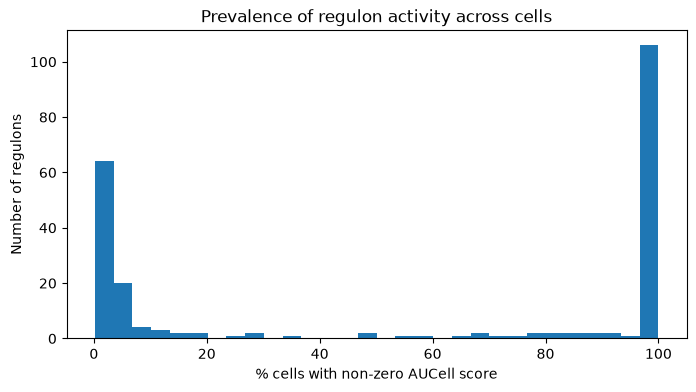

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(regulon_summary["pct_nonzero"], bins=30)
plt.xlabel("% cells with non-zero AUCell score")
plt.ylabel("Number of regulons")
plt.title("Prevalence of regulon activity across cells")
plt.show()

In [34]:
pd.cut(
    regulon_summary["pct_nonzero"],
    bins=[0, 1, 5, 20, 50, 80, 95, 100],
    include_lowest=True
).value_counts().sort_index()

pct_nonzero
(-0.001, 1.0]     17
(1.0, 5.0]        59
(5.0, 20.0]       19
(20.0, 50.0]       6
(50.0, 80.0]       9
(80.0, 95.0]       8
(95.0, 100.0]    107
Name: count, dtype: int64

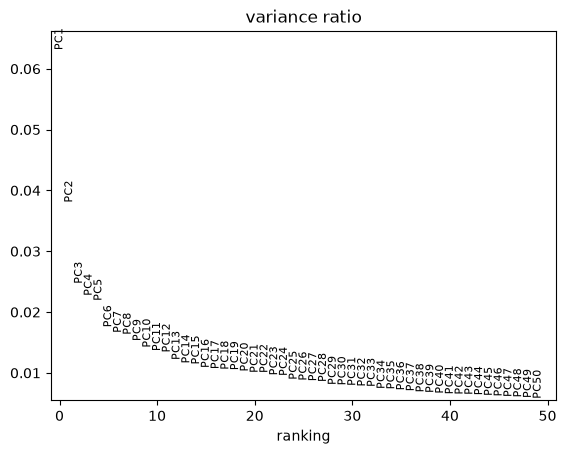

In [35]:
sc.tl.pca(adata_reg, n_comps=50)

sc.pl.pca_variance_ratio(
    adata_reg,
    n_pcs=50,
    log=False
)

In [36]:
pc1 = pd.Series(
    adata_reg.varm["PCs"][:, 0],
    index=adata_reg.var_names,
    name="PC1_loading"
)

pc1.sort_values()

ZNF619(+)   -0.131827
ZNF597(+)   -0.085019
TFEC(+)     -0.080269
ZNF697(+)   -0.078791
HOXC6(+)    -0.071263
               ...   
ZNF845(+)    0.205501
PBX4(+)      0.208828
ZNF350(+)    0.209584
ZNF225(+)    0.222868
FOXK1(+)     0.402412
Name: PC1_loading, Length: 225, dtype: float64

In [37]:
pc1_table = pd.DataFrame({
    "loading": pc1,
    "pct_nonzero": regulon_summary["pct_nonzero"]
})

pc1_table["abs_loading"] = pc1_table["loading"].abs()

pc1_table.sort_values(
    "abs_loading",
    ascending=False
).head(15)

,loading,pct_nonzero,abs_loading
FOXK1(+),0.402412,99.925227,0.402412
ZNF225(+),0.222868,99.962614,0.222868
ZNF350(+),0.209584,99.958460,0.209584
PBX4(+),0.208828,99.933535,0.208828
ZNF845(+),0.205501,99.908611,0.205501
KLF3(+),0.192903,99.459976,0.192903
ZFP3(+),0.192517,99.817223,0.192517
ZNF821(+),0.166730,99.950152,0.166730
CTCF(+),0.150716,98.791177,0.150716
AR(+),0.149669,99.945998,0.149669


In [38]:
pd.concat([
    pc1_table.sort_values("loading").head(10),
    pc1_table.sort_values("loading").tail(10)
])

,loading,pct_nonzero,abs_loading
ZNF619(+),-0.131827,2.695966,0.131827
ZNF597(+),-0.085019,17.962032,0.085019
TFEC(+),-0.080269,10.775558,0.080269
ZNF697(+),-0.078791,3.269223,0.078791
HOXC6(+),-0.071263,5.466705,0.071263
THAP11(+),-0.057897,5.138537,0.057897
ZNF627(+),-0.054765,2.986749,0.054765
OTX1(+),-0.051769,4.669131,0.051769
SPDEF(+),-0.049956,2.434262,0.049956
MNX1(+),-0.045619,14.775890,0.045619


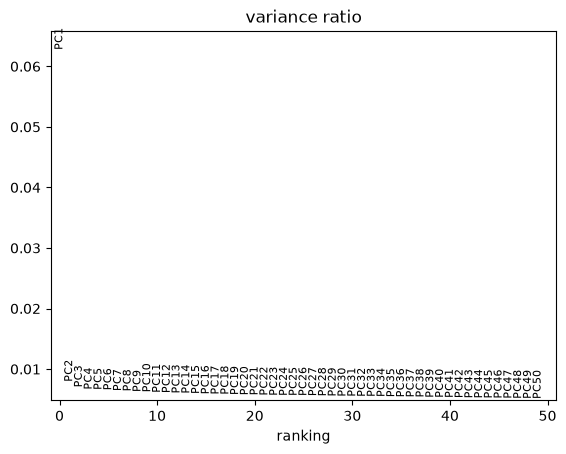

In [39]:
adata_reg_z = adata_reg.copy()

sc.pp.scale(adata_reg_z)

sc.tl.pca(adata_reg_z, n_comps=50)

sc.pl.pca_variance_ratio(
    adata_reg_z,
    n_pcs=50,
    log=False
)

In [40]:
pc1_z = pd.Series(
    adata_reg_z.varm["PCs"][:, 0],
    index=adata_reg_z.var_names,
    name="PC1_loading"
)

pc1_z_table = pd.DataFrame({
    "loading": pc1_z,
    "pct_nonzero": regulon_summary["pct_nonzero"]
})

pc1_z_table["abs_loading"] = pc1_z_table["loading"].abs()

pc1_z_table.sort_values(
    "abs_loading",
    ascending=False
).head(15)

,loading,pct_nonzero,abs_loading
FOXK1(+),0.208998,99.925227,0.208998
PBX4(+),0.205038,99.933535,0.205038
ZNF350(+),0.192837,99.958460,0.192837
FOS(+),0.190069,99.983384,0.190069
ZNF225(+),0.184634,99.962614,0.184634
RARA(+),0.183077,99.921073,0.183077
CEBPG(+),0.170075,99.916919,0.170075
ZNF761(+),0.154930,99.900303,0.154930
BHLHE40(+),0.145117,99.941844,0.145117
SMAD1(+),0.144846,99.788144,0.144846


In [41]:
pd.concat([
    pc1_z_table.sort_values("loading").head(10),
    pc1_z_table.sort_values("loading").tail(10)
])

,loading,pct_nonzero,abs_loading
JUND(+),-0.062526,26.901508,0.062526
ZNF597(+),-0.057558,17.962032,0.057558
NR2F1(+),-0.054480,66.572509,0.054480
FOXO6(+),-0.052179,24.683255,0.052179
MNX1(+),-0.050655,14.775890,0.050655
LHX9(+),-0.047631,35.845138,0.047631
ISL1(+),-0.043083,13.359365,0.043083
JUNB(+),-0.041169,14.015702,0.041169
ZNF48(+),-0.041139,11.336352,0.041139
TCF7L1(+),-0.039124,7.593570,0.039124


In [42]:
# Top regulons contributing to PC1-PC10
for i in range(10):
    pc = pd.Series(
        adata_reg_z.varm["PCs"][:, i],
        index=adata_reg_z.var_names
    )

    top = pc.abs().sort_values(ascending=False).head(10).index

    print(f"\nPC{i+1}")
    display(pd.DataFrame({
        "loading": pc.loc[top],
        "pct_nonzero": regulon_summary.loc[top, "pct_nonzero"]
    }).sort_values("loading"))


PC1


,loading,pct_nonzero
SMAD1(+),0.144846,99.788144
BHLHE40(+),0.145117,99.941844
ZNF761(+),0.154930,99.900303
CEBPG(+),0.170075,99.916919
RARA(+),0.183077,99.921073
ZNF225(+),0.184634,99.962614
FOS(+),0.190069,99.983384
ZNF350(+),0.192837,99.958460
PBX4(+),0.205038,99.933535
FOXK1(+),0.208998,99.925227



PC2


,loading,pct_nonzero
ZNF561(+),0.048785,80.629751
ZNF596(+),0.069616,2.463341
IKZF5(+),0.070899,1.125743
CREB5(+),0.071220,53.749013
IRF3(+),0.074154,70.240518
ZNF829(+),0.099928,0.648029
TBX15(+),0.146794,48.003988
THAP11(+),0.493629,5.138537
OSR1(+),0.534858,4.349271
ZNF274(+),0.606897,48.107839



PC3


...

,loading,pct_nonzero
E2F6(+),-0.282190,3.094753
ZNF649(+),-0.264856,2.388568
GMEB2(+),-0.191860,0.797574
MAFF(+),0.177943,98.895028
ELF4(+),0.202076,2.214099
IRX4(+),0.207111,99.995846
NR1H3(+),0.253253,2.185021
ZNF418(+),0.285842,6.347360
CREM(+),0.290785,0.922195
TP53(+),0.358058,0.245088



PC9


,loading,pct_nonzero
BACH2(+),-0.174521,3.069829
GMEB2(+),0.172086,0.797574
BHLHE41(+),0.178264,99.979230
TFAP2C(+),0.181105,99.979230
FOXC1(+),0.182261,99.970922
ELF3(+),0.199709,97.623894
PLAGL2(+),0.247270,1.678229
USF1(+),0.330090,85.477506
ZNF649(+),0.334009,2.388568
E2F6(+),0.354200,3.094753



PC10


,loading,pct_nonzero
USF1(+),-0.142437,85.477506
EN2(+),0.133138,99.235658
ZNF649(+),0.135067,2.388568
ZNF561(+),0.135367,80.629751
VAX2(+),0.138949,99.979230
E2F6(+),0.144984,3.094753
ZSCAN29(+),0.146188,1.067586
IRX4(+),0.276764,99.995846
CREM(+),0.364963,0.922195
ZNF418(+),0.402075,6.347360


In [43]:
import numpy as np
import pandas as pd

variance_ratio = adata_reg_z.uns["pca"]["variance_ratio"]

pd.DataFrame({
    "PC": np.arange(1, len(variance_ratio) + 1),
    "variance_%": variance_ratio * 100,
    "cumulative_%": np.cumsum(variance_ratio) * 100
}).head(30)

,PC,variance_%,cumulative_%
0,1,6.272019,6.272019
1,2,0.790601,7.062621
2,3,0.698487,7.761108
3,4,0.661707,8.422815
4,5,0.656672,9.079487
5,6,0.650403,9.729889
6,7,0.637158,10.367047
7,8,0.632527,10.999574
8,9,0.621730,11.621304
9,10,0.617349,12.238653


In [44]:
# UMAP using PC1-PC10
sc.pp.neighbors(
    adata_reg_z,
    n_neighbors=15,
    n_pcs=10,
    key_added="neighbors_pcs10"
)

sc.tl.umap(
    adata_reg_z,
    neighbors_key="neighbors_pcs10"
)

adata_reg_z.obsm["X_umap_pcs10"] = adata_reg_z.obsm["X_umap"].copy()

/Users/serafimaabakumova/miniforge3/envs/scrna/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


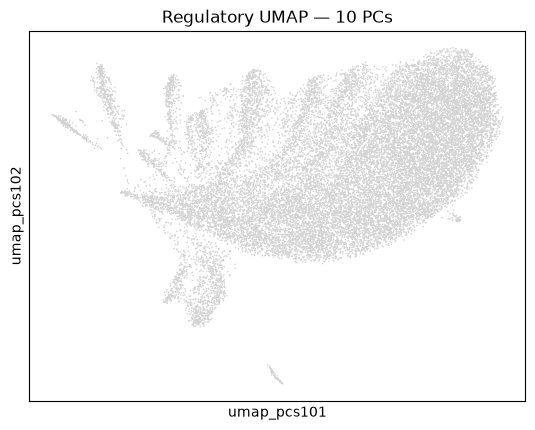

In [45]:
sc.pl.embedding(
    adata_reg_z,
    basis="umap_pcs10",
    title="Regulatory UMAP — 10 PCs"
)

In [46]:
# UMAP — PC1-PC20
sc.pp.neighbors(
    adata_reg_z,
    n_neighbors=15,
    n_pcs=20,
    key_added="neighbors_pcs20"
)

sc.tl.umap(
    adata_reg_z,
    neighbors_key="neighbors_pcs20"
)

adata_reg_z.obsm["X_umap_pcs20"] = adata_reg_z.obsm["X_umap"].copy()


# UMAP — PC1-PC30
sc.pp.neighbors(
    adata_reg_z,
    n_neighbors=15,
    n_pcs=30,
    key_added="neighbors_pcs30"
)

sc.tl.umap(
    adata_reg_z,
    neighbors_key="neighbors_pcs30"
)

adata_reg_z.obsm["X_umap_pcs30"] = adata_reg_z.obsm["X_umap"].copy()

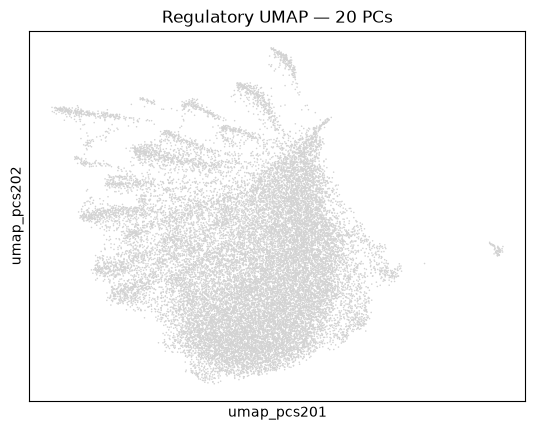

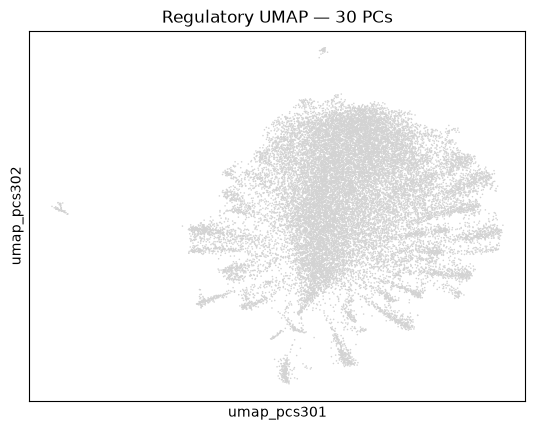

In [48]:
sc.pl.embedding(
    adata_reg_z,
    basis="umap_pcs20",
    title="Regulatory UMAP — 20 PCs"
)

sc.pl.embedding(
    adata_reg_z,
    basis="umap_pcs30",
    title="Regulatory UMAP — 30 PCs"
)

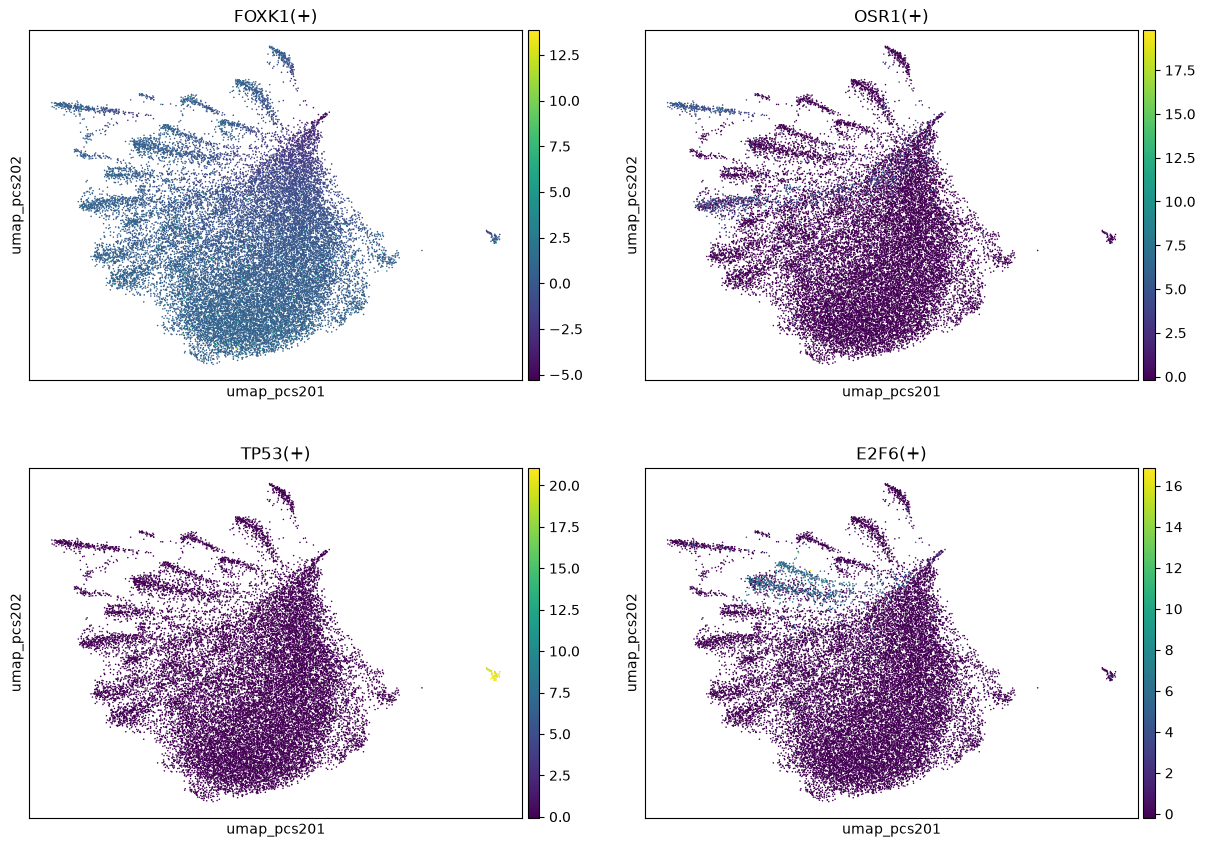

In [49]:
sc.pl.embedding(
    adata_reg_z,
    basis="umap_pcs20",
    color=["FOXK1(+)", "OSR1(+)", "TP53(+)", "E2F6(+)"],
    ncols=2
)

In [50]:
regulon_corr = regulon_table.corr(method="spearman")

print(regulon_corr.shape)
regulon_corr.iloc[:5, :5]

(225, 225)


,AR(+),ARID3A(+),ATF3(+),BACH2(+),BCL11A(+)
AR(+),1.000000,0.499525,0.582703,-0.066868,-0.076325
ARID3A(+),0.499525,1.000000,0.379496,-0.044299,-0.058937
ATF3(+),0.582703,0.379496,1.000000,-0.043539,-0.050123
BACH2(+),-0.066868,-0.044299,-0.043539,1.000000,0.017039
BCL11A(+),-0.076325,-0.058937,-0.050123,0.017039,1.000000


In [51]:
import numpy as np

upper_triangle = regulon_corr.where(
    np.triu(np.ones(regulon_corr.shape), k=1).astype(bool)
).stack()

upper_triangle.describe()

count    25200.000000
mean         0.161152
std          0.303454
min         -0.177329
25%         -0.046213
50%         -0.002571
75%          0.395482
max          0.961115
dtype: float64

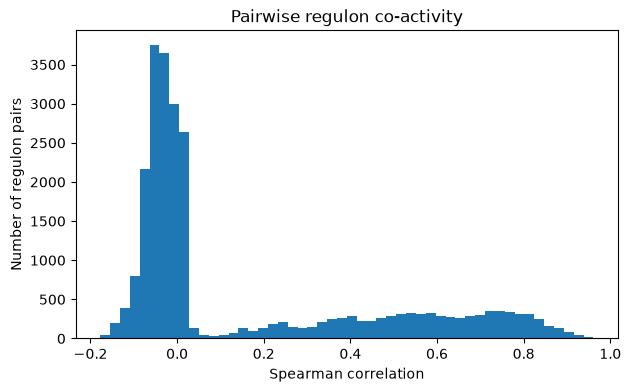

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(upper_triangle, bins=50)
plt.xlabel("Spearman correlation")
plt.ylabel("Number of regulon pairs")
plt.title("Pairwise regulon co-activity")
plt.show()

/Users/serafimaabakumova/miniforge3/envs/scrna/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/serafimaabakumova/miniforge3/envs/scrna/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


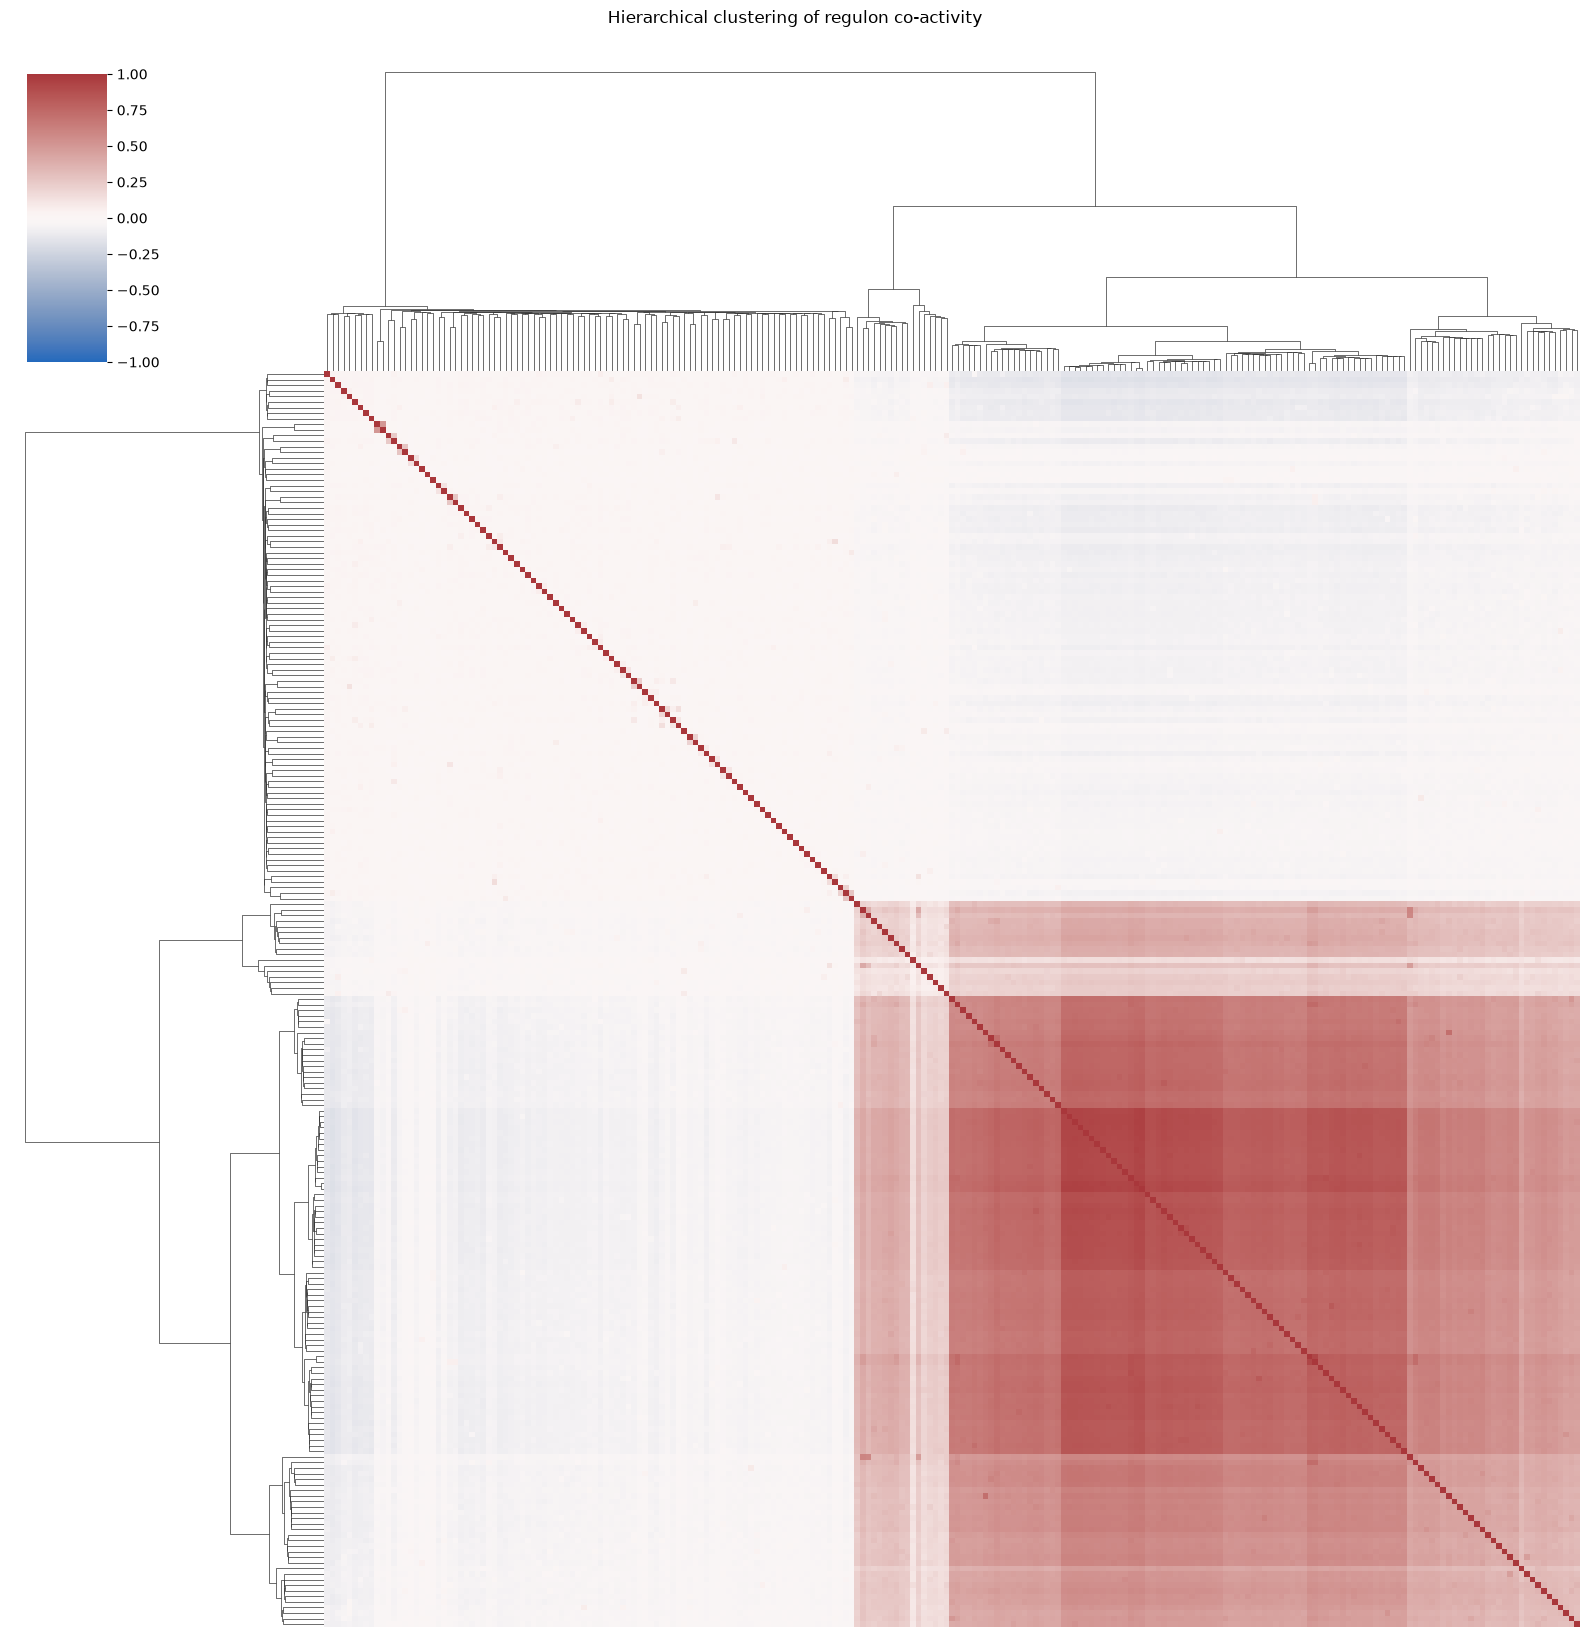

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.clustermap(
    regulon_corr,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    figsize=(16, 16),
    xticklabels=False,
    yticklabels=False
)

g.fig.suptitle(
    "Hierarchical clustering of regulon co-activity",
    y=1.02
)

plt.show()

In [54]:
# Order of regulons produced by hierarchical clustering
cluster_order = g.dendrogram_row.reordered_ind

ordered_regulons = regulon_corr.index[cluster_order]

prevalence_ordered = regulon_summary.loc[
    ordered_regulons, "pct_nonzero"
]

prevalence_ordered

MNX1(+)      14.775890
JUND(+)      26.901508
ZNF597(+)    17.962032
JUNB(+)      14.015702
TBX1(+)       9.155485
               ...    
ERF(+)       99.970922
EN2(+)       99.235658
SP5(+)       79.171686
NRL(+)       74.884726
VAX2(+)      99.979230
Name: pct_nonzero, Length: 225, dtype: float64

In [55]:
from scipy.stats import spearmanr
import numpy as np

cluster_position = np.arange(len(prevalence_ordered))

rho, p = spearmanr(
    cluster_position,
    prevalence_ordered.values
)

print("Spearman rho:", rho)
print("p-value:", p)

Spearman rho: 0.6935898571322614
p-value: 1.315403676673815e-33


In [56]:
unique_values = regulon_table.nunique()

unique_values.describe()

count     225.000000
mean      501.911111
std       430.828480
min        25.000000
25%       153.000000
50%       381.000000
75%       760.000000
max      1962.000000
dtype: float64

In [57]:
unique_values.sort_values().head(15)

THRB(+)       25
TP53(+)       34
ZBTB25(+)     39
ZNF614(+)     57
PKNOX1(+)     63
ZNF577(+)     64
ZNF394(+)     69
HES1(+)       71
ZNF384(+)     74
ZNF521(+)     74
ZSCAN29(+)    75
CREM(+)       75
IKZF5(+)      78
ZNF441(+)     79
ZFP90(+)      82
dtype: int64

In [58]:
from sklearn.decomposition import NMF
import pandas as pd

# cells × regulons: original non-negative AUCell scores
X = regulon_table.values

nmf = NMF(
    n_components=8,
    init="nndsvda",
    random_state=42,
    max_iter=1000
)

# activity of each program in each cell
W = nmf.fit_transform(X)

# contribution of each regulon to each program
H = nmf.components_

program_activity = pd.DataFrame(
    W,
    index=regulon_table.index,
    columns=[f"Program_{i+1}" for i in range(8)]
)

program_loadings = pd.DataFrame(
    H.T,
    index=regulon_table.columns,
    columns=[f"Program_{i+1}" for i in range(8)]
)

print("Program activity:", program_activity.shape)
print("Program loadings:", program_loadings.shape)
print("Reconstruction error:", nmf.reconstruction_err_)

Program activity: (24073, 8)
Program loadings: (225, 8)
Reconstruction error: 35.86089636625498


In [59]:
for program in program_loadings.columns:
    print(f"\n{program}")
    print(
        program_loadings[program]
        .sort_values(ascending=False)
        .head(10)
    )


Program_1
FOXK1(+)     2.965085
ZNF225(+)    2.824833
ZNF350(+)    2.756761
ZNF821(+)    1.970334
HSF1(+)      1.817564
AR(+)        1.768911
PBX4(+)      1.699819
ZNF79(+)     1.692934
ZFP3(+)      1.552779
ZNF845(+)    1.524389
Name: Program_1, dtype: float64

Program_2
ZNF619(+)    2.962307
ZBTB25(+)    0.195033
ZNF225(+)    0.114277
ZNF350(+)    0.103222
AR(+)        0.079672
ZNF821(+)    0.075754
FOXK1(+)     0.073606
DBP(+)       0.066618
HSF1(+)      0.065965
ZNF79(+)     0.058175
Name: Program_2, dtype: float64

Program_3
ZNF697(+)    3.966033
ZNF225(+)    0.211799
ZNF350(+)    0.209435
ZNF821(+)    0.172711
HSF1(+)      0.158878
FOXK1(+)     0.137653
ZNF79(+)     0.124249
AR(+)        0.121514
ZNF579(+)    0.114453
HOXC10(+)    0.112720
Name: Program_3, dtype: float64

Program_4
IKZF5(+)     2.088824
ZNF596(+)    1.548252
ZNF350(+)    0.094928
ZNF225(+)    0.091992
AR(+)        0.070508
FOXK1(+)     0.069631
HSF1(+)      0.062392
ZNF821(+)    0.059412
ZNF79(+)     0.056757
KL

In [60]:
from sklearn.decomposition import NMF

errors = {}

for k in [4, 6, 8, 10, 12]:
    model = NMF(
        n_components=k,
        init="nndsvda",
        random_state=42,
        max_iter=1000
    )
    
    model.fit(regulon_table.values)
    errors[k] = model.reconstruction_err_

errors

{4: np.float64(37.533908440661214),
 6: np.float64(36.60820468786562),
 8: np.float64(35.86089636625498),
 10: np.float64(35.143479828575735),
 12: np.float64(34.51184892823597)}

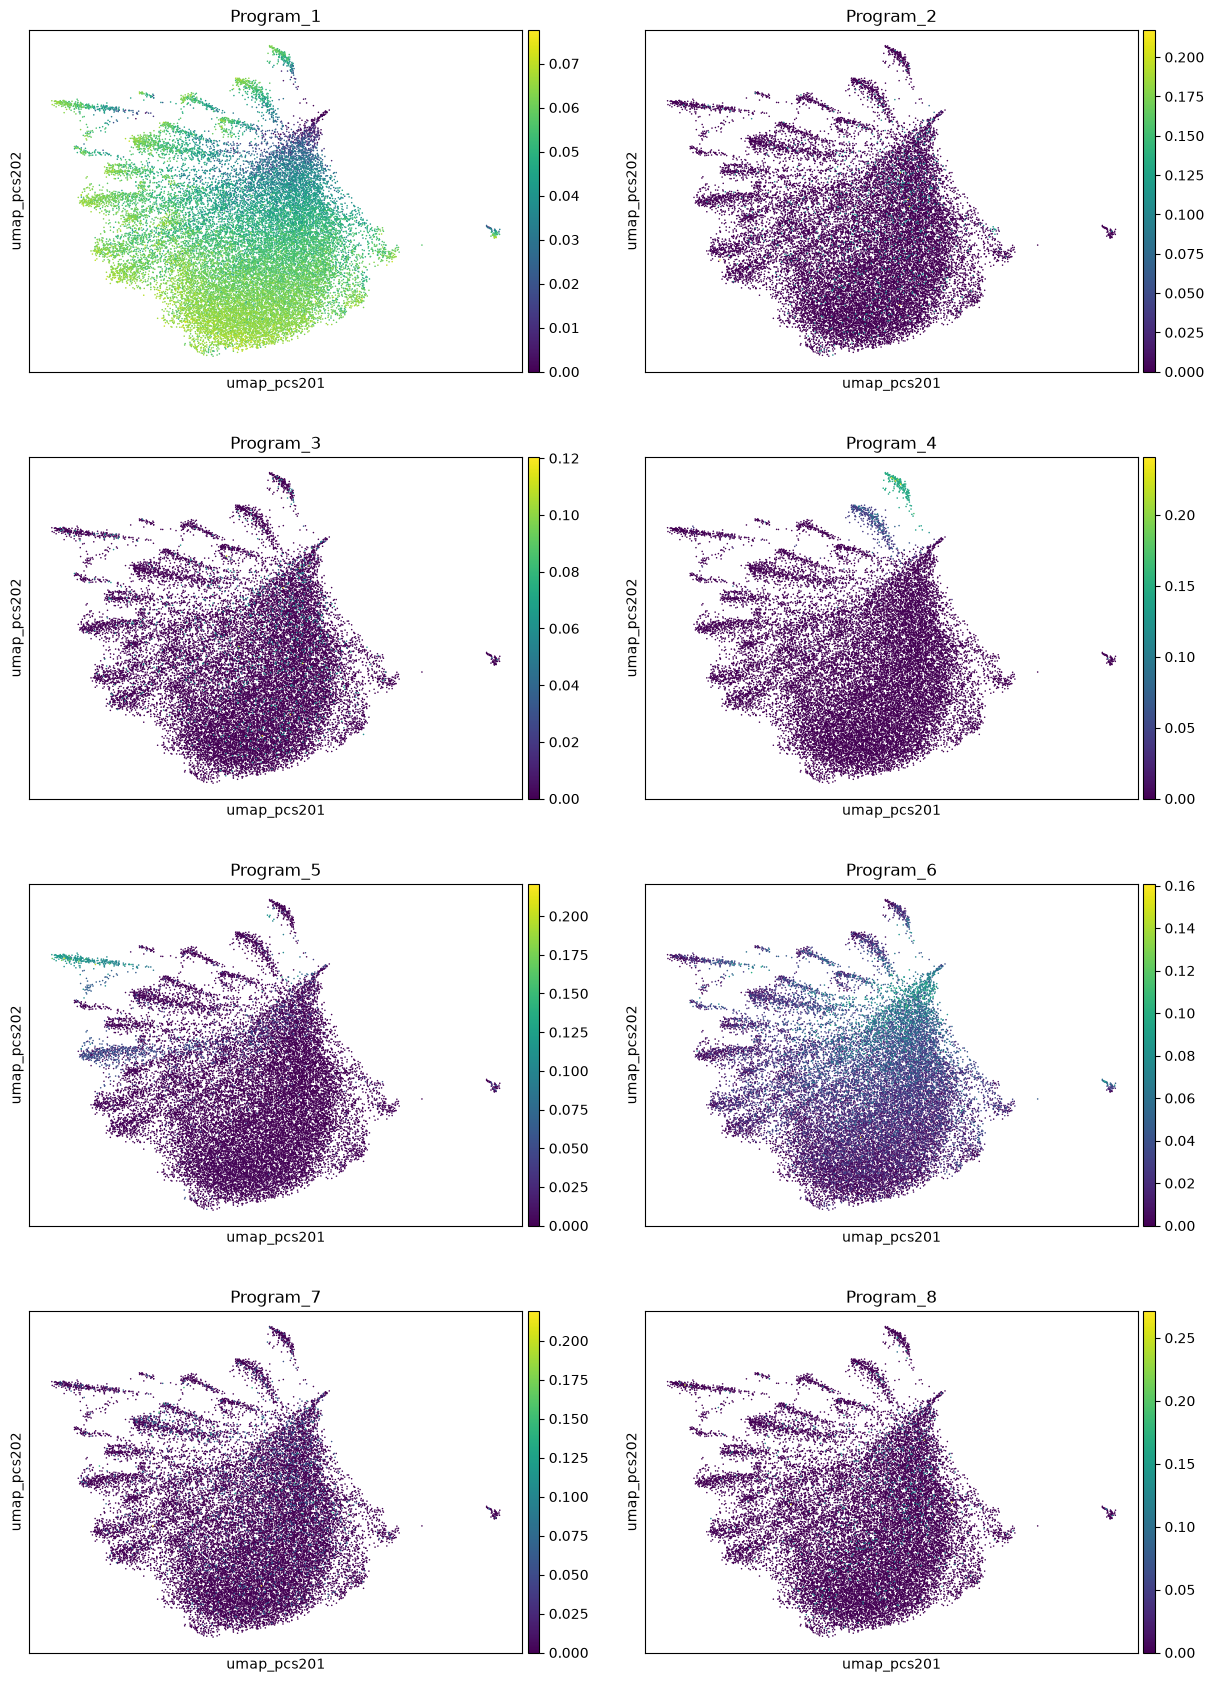

In [61]:
# Add NMF component activity to each cell
for program in program_activity.columns:
    adata_reg_z.obs[program] = program_activity.loc[
        adata_reg_z.obs_names, program
    ].values

# Plot NMF components on the EXISTING regulatory UMAP
sc.pl.embedding(
    adata_reg_z,
    basis="umap_pcs20",
    color=[
        "Program_1",
        "Program_2",
        "Program_3",
        "Program_4",
        "Program_5",
        "Program_6",
        "Program_7",
        "Program_8"
    ],
    ncols=2,
    cmap="viridis"
)

In [62]:
loading_fraction = program_loadings.div(
    program_loadings.sum(axis=0),
    axis=1
)

for program in loading_fraction.columns:
    top = loading_fraction[program].sort_values(ascending=False).head(10)
    
    print(f"\n{program}")
    print(top)
    print("Top 10 total weight:", round(top.sum(), 3))


Program_1
FOXK1(+)     0.036648
ZNF225(+)    0.034914
ZNF350(+)    0.034073
ZNF821(+)    0.024353
HSF1(+)      0.022465
AR(+)        0.021863
PBX4(+)      0.021009
ZNF79(+)     0.020924
ZFP3(+)      0.019192
ZNF845(+)    0.018841
Name: Program_1, dtype: float64
Top 10 total weight: 0.254

Program_2
ZNF619(+)    0.447521
ZBTB25(+)    0.029464
ZNF225(+)    0.017264
ZNF350(+)    0.015594
AR(+)        0.012036
ZNF821(+)    0.011444
FOXK1(+)     0.011120
DBP(+)       0.010064
HSF1(+)      0.009965
ZNF79(+)     0.008789
Name: Program_2, dtype: float64
Top 10 total weight: 0.573

Program_3
ZNF697(+)    0.375770
ZNF225(+)    0.020067
ZNF350(+)    0.019843
ZNF821(+)    0.016364
HSF1(+)      0.015053
FOXK1(+)     0.013042
ZNF79(+)     0.011772
AR(+)        0.011513
ZNF579(+)    0.010844
HOXC10(+)    0.010680
Name: Program_3, dtype: float64
Top 10 total weight: 0.505

Program_4
IKZF5(+)     0.312144
ZNF596(+)    0.231363
ZNF350(+)    0.014186
ZNF225(+)    0.013747
AR(+)        0.010536
FOXK1(+) 

In [63]:
regulons = pd.read_csv(
    "MB231_regulons.csv",
    header=[0, 1],
    index_col=[0, 1]
)

print(regulons.columns)

MultiIndex([('Enrichment',                   'AUC'),
            ('Enrichment',                   'NES'),
            ('Enrichment', 'MotifSimilarityQvalue'),
            ('Enrichment',   'OrthologousIdentity'),
            ('Enrichment',            'Annotation'),
            ('Enrichment',               'Context'),
            ('Enrichment',           'TargetGenes'),
            ('Enrichment',             'RankAtMax')],
           )


In [64]:
regulons.head(2)

Enrichment  \
                                                                  AUC   
TF      MotifID                                                         
ARID3A  metacluster_101.6                                    0.094156   
BHLHE41 taipale_tf_pairs__ARNTL_PITX1_NNCACGTGNNNNRGMTT...   0.075875   

                                                                      \
                                                                 NES   
TF      MotifID                                                        
ARID3A  metacluster_101.6                                   3.402090   
BHLHE41 taipale_tf_pairs__ARNTL_PITX1_NNCACGTGNNNNRGMTT...  3.002609   

                                                                                  \
                                                           MotifSimilarityQvalue   
TF      MotifID                                                                    
ARID3A  metacluster_101.6                                           2.278410e-25   
BHLHE41 taipale_tf_pairs__ARNTL_PITX1_NNCACGTGNNNNRGMTT...          2.807980e-06   

                                                                                \
                                                           OrthologousIdentity   
TF      MotifID                                                                  
ARID3A  metacluster_101.6                                             1.000000   
BHLHE41 taipale_tf_pairs__ARNTL_PITX1_NNCACGTGNNNNRGMTT...            0.721992   

                                                                                                               \
                                                                                                   Annotation   
TF      MotifID                                                                                                 
ARID3A  metacluster_101.6                                   motif similar to dbtfbs__ARID3A_representative...   
BHLHE41 taipale_tf_pairs__ARNTL_PITX1_NNCACGTGNNNNRGMTT...  gene is orthologous to ENSMUSG00000030256 in M...   

                                                                                                               \
                                                                                                      Context   
TF      MotifID                                                                                                 
ARID3A  metacluster_101.6                                   frozenset({'activating', 'weight>75.0%', 'hg38...   
BHLHE41 taipale_tf_pairs__ARNTL_PITX1_NNCACGTGNNNNRGMTT...  frozenset({'activating', 'weight>75.0%', 'hg38...   

                                                                                                               \
                                                                                                  TargetGenes   
TF      MotifID                                                                                                 
ARID3A  metacluster_101.6                                   [('SAMD8', 0.7828186508255598), ('TMEM39A', 1....   
BHLHE41 taipale_tf_pairs__ARNTL_PITX1_NNCACGTGNNNNRGMTT...  [('ABR', 2.6191237710936934), ('TFPI', 1.29748...   

                                                                      
                                                           RankAtMax  
TF      MotifID                                                       
ARID3A  metacluster_101.6                                       1011  
BHLHE41 taipale_tf_pairs__ARNTL_PITX1_NNCACGTGNNNNRGMTT...       302

In [65]:
import ast
from collections import defaultdict

# TargetGenes column
target_col = ("Enrichment", "TargetGenes")

tf_targets = defaultdict(set)

for (tf, motif), row in regulons.iterrows():
    targets = row[target_col]

    # pySCENIC may store the list as a string in CSV
    if isinstance(targets, str):
        targets = ast.literal_eval(targets)

    # Each item = (target_gene, importance_weight)
    for gene, weight in targets:
        tf_targets[tf].add(gene)

tf_targets = {
    tf: sorted(genes)
    for tf, genes in tf_targets.items()
}

print("TFs with targets:", len(tf_targets))

# Quick sanity check
for tf in list(tf_targets)[:5]:
    print(tf, len(tf_targets[tf]), tf_targets[tf][:10])

TFs with targets: 225
ARID3A 57 ['ADORA2B', 'ARID3A', 'BAG4', 'BPGM', 'BRI3BP', 'CCDC9', 'CEP104', 'CHMP2A', 'CHTOP', 'COTL1']
BHLHE41 45 ['ABR', 'ANOS1', 'ATP8B1', 'AUNIP', 'BCL7B', 'CEP78', 'CNOT3', 'CNTNAP3', 'COL7A1', 'DCUN1D5']
CEBPB 74 ['ABHD16A', 'ABI1', 'ARL8B', 'ASB1', 'ATG13', 'ATMIN', 'BMPER', 'CCNL2', 'CENPN', 'CFAP97']
CREB5 29 ['AIFM2', 'AKIRIN2', 'ATG3', 'CHST3', 'CREB5', 'EEF1AKMT1', 'FXR2', 'GIN1', 'HAUS1', 'ITGA1']
E2F1 31 ['CALB1', 'CARD8', 'COG6', 'COPS4', 'DLEU1', 'DYNC1I1', 'E2F1', 'FKBP9', 'FOSB', 'HEXA']


In [66]:
main_programs = ["Program_1", "Program_4", "Program_5", "Program_6"]

program_gene_sets = {}
program_regulons = {}

for program in main_programs:
    weights = loading_fraction[program].sort_values(ascending=False)
    cumulative = weights.cumsum()

    # Regulons contributing to first 80% of component weight
    selected = list(weights[cumulative <= 0.80].index)

    # Include the regulon that crosses the 80% boundary
    if len(selected) < len(weights):
        selected.append(weights.index[len(selected)])

    program_regulons[program] = selected

    genes = set()
    for regulon_name in selected:
        tf = regulon_name.replace("(+)", "")
        genes.update(tf_targets.get(tf, []))

    program_gene_sets[program] = sorted(genes)

    print(
        program,
        "| regulons:", len(selected),
        "| target genes:", len(genes)
    )

Program_1 | regulons: 68 | target genes: 1388
Program_4 | regulons: 48 | target genes: 752
Program_5 | regulons: 28 | target genes: 392
Program_6 | regulons: 98 | target genes: 2144


In [67]:
for program in main_programs:
    print(f"\n{program}")
    print(program_regulons[program])


Program_1
['FOXK1(+)', 'ZNF225(+)', 'ZNF350(+)', 'ZNF821(+)', 'HSF1(+)', 'AR(+)', 'PBX4(+)', 'ZNF79(+)', 'ZFP3(+)', 'ZNF845(+)', 'PRDM4(+)', 'ZNF761(+)', 'HOXC4(+)', 'HOXC10(+)', 'ZNF669(+)', 'FOS(+)', 'ZNF579(+)', 'ZNF501(+)', 'KLF3(+)', 'ZNF691(+)', 'MXD4(+)', 'CEBPG(+)', 'SMAD1(+)', 'ZNF518B(+)', 'RARA(+)', 'ZNF543(+)', 'ZBTB33(+)', 'FOXO1(+)', 'BHLHE40(+)', 'ZNF518A(+)', 'MEF2B(+)', 'STAT6(+)', 'ZNF786(+)', 'ZNF202(+)', 'CTCF(+)', 'DBP(+)', 'MZF1(+)', 'BCL6(+)', 'ETS2(+)', 'FOXC1(+)', 'SOX6(+)', 'POU5F1(+)', 'ZNF467(+)', 'PRDM16(+)', 'OVOL2(+)', 'TEAD4(+)', 'TFAP2C(+)', 'ZNF799(+)', 'FOXA2(+)', 'NKX3-1(+)', 'ZNF263(+)', 'E2F2(+)', 'DMBX1(+)', 'ZSCAN20(+)', 'ETV4(+)', 'MYB(+)', 'ZNF362(+)', 'HDX(+)', 'MEIS1(+)', 'ARID3A(+)', 'GATA3(+)', 'ETV7(+)', 'GATA2(+)', 'PAX5(+)', 'HOXB6(+)', 'NR2F6(+)', 'E2F1(+)', 'IRF9(+)']

Program_4
['IKZF5(+)', 'ZNF596(+)', 'ZNF350(+)', 'ZNF225(+)', 'AR(+)', 'FOXK1(+)', 'HSF1(+)', 'ZNF821(+)', 'ZNF79(+)', 'KLF3(+)', 'HOXC10(+)', 'FOS(+)', 'PBX4(+)', 'ZNF

In [68]:
program_gene_sets = {}
program_regulons = {}

for program in program_loadings.columns:
    
    top_regulons = (
        program_loadings[program]
        .sort_values(ascending=False)
        .head(10)
        .index
        .tolist()
    )
    
    genes = set()
    
    for regulon in top_regulons:
        tf = regulon.replace("(+)", "")
        genes.update(tf_targets[tf])
    
    program_regulons[program] = top_regulons
    program_gene_sets[program] = sorted(genes)
    
    print(
        program,
        "| regulons:", len(top_regulons),
        "| target genes:", len(genes)
    )

Program_1 | regulons: 10 | target genes: 77
Program_2 | regulons: 10 | target genes: 102
Program_3 | regulons: 10 | target genes: 78
Program_4 | regulons: 10 | target genes: 66
Program_5 | regulons: 10 | target genes: 95
Program_6 | regulons: 10 | target genes: 84
Program_7 | regulons: 10 | target genes: 78
Program_8 | regulons: 10 | target genes: 80


In [69]:
from gprofiler import GProfiler
import pandas as pd

gp = GProfiler(return_dataframe=True)

enrichment_results = {}

for program, genes in program_gene_sets.items():
    
    result = gp.profile(
        organism="hsapiens",
        query=genes,
        sources=["GO:BP", "REAC", "WP"]
    )
    
    enrichment_results[program] = result
    
    print(f"\n{program}")
    
    if len(result) == 0:
        print("No significant terms")
    else:
        display(
            result[
                ["source", "name", "p_value", "intersection_size"]
            ].head(10)
        )


Program_1


,source,name,p_value,intersection_size
0,GO:BP,transcription by RNA polymerase II,6.624658e-07,30
1,GO:BP,regulation of transcription by RNA polymerase II,1.041024e-06,29
2,GO:BP,DNA-templated transcription,1.384694e-06,33
3,GO:BP,regulation of DNA-templated transcription,1.124916e-05,31
4,GO:BP,regulation of RNA biosynthetic process,1.226823e-05,31
5,GO:BP,regulation of RNA metabolic process,1.660796e-05,32
6,GO:BP,regulation of nucleobase-containing compound m...,1.169003e-04,32
7,GO:BP,regulation of gene expression,9.126200e-04,37
8,GO:BP,regulation of macromolecule biosynthetic process,1.456533e-03,37
9,GO:BP,nucleobase-containing compound metabolic process,1.922958e-03,45



Program_2


,source,name,p_value,intersection_size
0,GO:BP,regulation of RNA metabolic process,0.000008,40
1,GO:BP,DNA-templated transcription,0.000010,39
2,GO:BP,regulation of DNA-templated transcription,0.000012,38
3,GO:BP,regulation of RNA biosynthetic process,0.000013,38
4,GO:BP,transcription by RNA polymerase II,0.000021,34
5,GO:BP,regulation of transcription by RNA polymerase II,0.000023,33
6,GO:BP,regulation of nucleobase-containing compound m...,0.000077,40
7,GO:BP,regulation of gene expression,0.001798,46
8,GO:BP,regulation of primary metabolic process,0.002376,44
9,GO:BP,regulation of macromolecule biosynthetic process,0.003064,46



Program_3


...

,source,name,p_value,intersection_size
0,GO:BP,DNA-templated transcription,0.000122,33
1,GO:BP,regulation of nucleobase-containing compound m...,0.000159,35
2,GO:BP,regulation of DNA-templated transcription,0.000176,32
3,GO:BP,regulation of RNA biosynthetic process,0.000192,32
4,GO:BP,regulation of transcription by RNA polymerase II,0.000225,28
5,GO:BP,regulation of RNA metabolic process,0.000298,33
6,GO:BP,transcription by RNA polymerase II,0.000652,28
7,GO:BP,regulation of primary metabolic process,0.001779,39
8,GO:BP,regulation of biosynthetic process,0.011238,40
9,WP,RANKL RANK signaling,0.012440,4



Program_7


,source,name,p_value,intersection_size
0,GO:BP,regulation of transcription by RNA polymerase II,3.822006e-08,32
1,GO:BP,DNA-templated transcription,8.508870e-08,36
2,GO:BP,regulation of DNA-templated transcription,1.386248e-07,35
3,GO:BP,transcription by RNA polymerase II,1.455122e-07,32
4,GO:BP,regulation of RNA biosynthetic process,1.533365e-07,35
5,GO:BP,regulation of RNA metabolic process,2.473554e-07,36
6,GO:BP,regulation of nucleobase-containing compound m...,2.385151e-06,36
7,GO:BP,nucleobase-containing compound biosynthetic pr...,3.090238e-05,47
8,GO:BP,nucleobase-containing compound metabolic process,4.771589e-05,50
9,GO:BP,regulation of primary metabolic process,3.523283e-04,38



Program_8


,source,name,p_value,intersection_size
0,GO:BP,regulation of transcription by RNA polymerase II,0.000001,30
1,GO:BP,regulation of nucleobase-containing compound m...,0.000002,36
2,GO:BP,transcription by RNA polymerase II,0.000004,30
3,GO:BP,regulation of RNA metabolic process,0.000005,34
4,GO:BP,DNA-templated transcription,0.000009,33
5,GO:BP,regulation of DNA-templated transcription,0.000015,32
6,GO:BP,regulation of RNA biosynthetic process,0.000016,32
7,GO:BP,regulation of primary metabolic process,0.000352,38
8,GO:BP,regulation of gene expression,0.001913,38
9,GO:BP,regulation of macromolecule metabolic process,0.002826,41


In [70]:
generic_terms = [
    "transcription",
    "RNA metabolic",
    "RNA biosynthetic",
    "gene expression",
    "nucleobase-containing",
    "biosynthetic process",
    "metabolic process"
]

specific_enrichment = {}

for program, result in enrichment_results.items():
    
    mask = ~result["name"].str.contains(
        "|".join(generic_terms),
        case=False,
        regex=True
    )
    
    specific = result.loc[mask].copy()
    specific_enrichment[program] = specific
    
    print(f"\n--- {program} ---")
    
    display(
        specific[
            ["source", "name", "p_value", "intersection_size"]
        ].head(10)
    )


--- Program_1 ---


,source,name,p_value,intersection_size



--- Program_2 ---


,source,name,p_value,intersection_size
14,GO:BP,TRIF-dependent toll-like receptor signaling pa...,0.038413,3



--- Program_3 ---


...

,source,name,p_value,intersection_size
9,WP,RANKL RANK signaling,0.012440,4
12,WP,IL18 signaling,0.019448,4
17,WP,Leptin signaling,0.048945,4



--- Program_7 ---


,source,name,p_value,intersection_size



--- Program_8 ---


,source,name,p_value,intersection_size
14,WP,RANKL RANK signaling,0.008920,4
16,WP,IL18 signaling,0.013967,4
20,WP,Urotensin II mediated signaling,0.031594,4


In [71]:
print("Shape:", adata.shape)
print("\nobs columns:")
print(adata.obs.columns.tolist())

print("\nobsm:")
print(list(adata.obsm.keys()))

print("\nuns:")
print(list(adata.uns.keys()))

Shape: (24073, 16432)

obs columns:
['bc_wells', 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes']

obsm:
[]

uns:
['log1p']


In [72]:
# Make a copy for expression-space comparison
adata_expr = adata.copy()

# adata.X is already normalized/log-transformed but scaled,
# so PCA can be calculated directly
sc.tl.pca(adata_expr, n_comps=50)

sc.pp.neighbors(
    adata_expr,
    n_neighbors=15,
    n_pcs=20
)

sc.tl.umap(adata_expr, random_state=42)

print(adata_expr.obsm["X_umap"].shape)

(24073, 2)


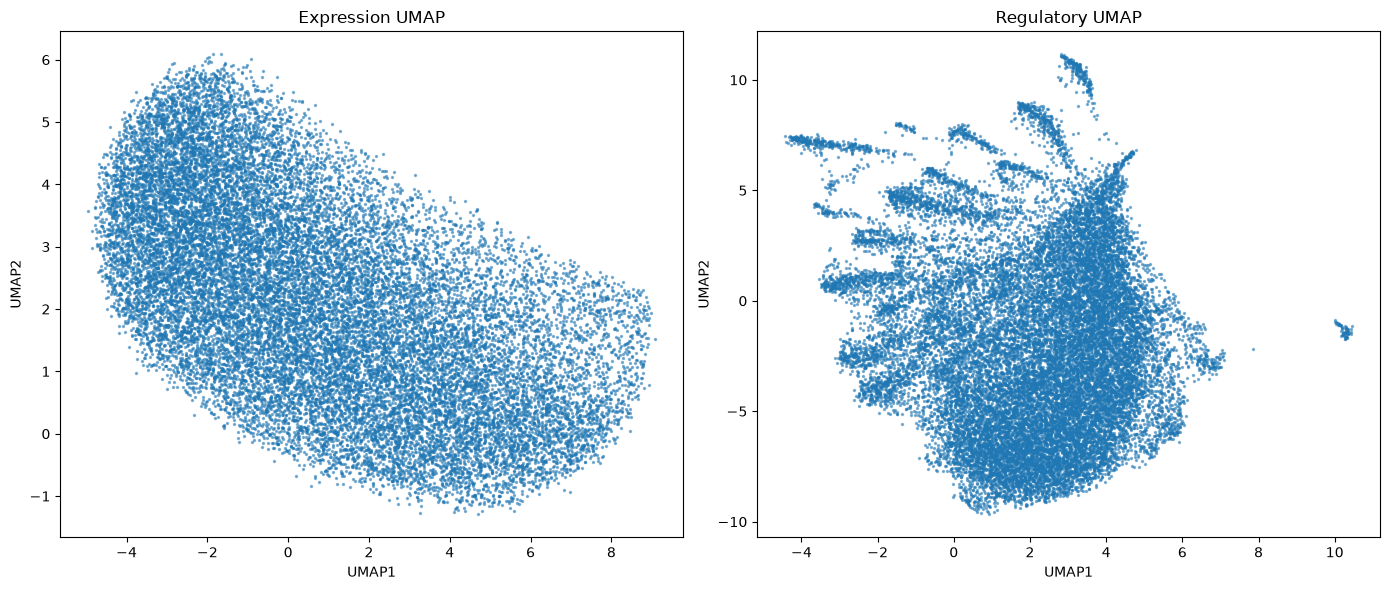

In [73]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    adata_expr.obsm["X_umap"][:, 0],
    adata_expr.obsm["X_umap"][:, 1],
    s=2,
    alpha=0.5
)
axes[0].set_title("Expression UMAP")
axes[0].set_xlabel("UMAP1")
axes[0].set_ylabel("UMAP2")

axes[1].scatter(
    adata_reg_z.obsm["X_umap_pcs20"][:, 0],
    adata_reg_z.obsm["X_umap_pcs20"][:, 1],
    s=2,
    alpha=0.5
)
axes[1].set_title("Regulatory UMAP")
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")

plt.tight_layout()
plt.show()

In [74]:
import pandas as pd
import os

os.makedirs("app_data", exist_ok=True)

# ---------- CELL-LEVEL DATA ----------

cell_data = pd.DataFrame(
    index=adata_reg_z.obs_names
)

# Expression UMAP
cell_data["expr_umap1"] = adata_expr.obsm["X_umap"][:, 0]
cell_data["expr_umap2"] = adata_expr.obsm["X_umap"][:, 1]

# Regulatory UMAP
cell_data["reg_umap1"] = adata_reg_z.obsm["X_umap_pcs20"][:, 0]
cell_data["reg_umap2"] = adata_reg_z.obsm["X_umap_pcs20"][:, 1]

# NMF components
for program in program_activity.columns:
    cell_data[program] = program_activity.loc[
        cell_data.index, program
    ]

cell_data.to_csv("app_data/cell_data.csv")


# ---------- REGULON ACTIVITY ----------

regulon_table.loc[cell_data.index].to_csv(
    "app_data/regulon_activity.csv"
)


# ---------- REGULON SUMMARY ----------

regulon_summary.to_csv(
    "app_data/regulon_summary.csv"
)


# ---------- NMF LOADINGS ----------

program_loadings.to_csv(
    "app_data/program_loadings.csv"
)


# ---------- PROGRAM REGULONS ----------

program_regulon_table = []

for program, regulons_list in program_regulons.items():
    for rank, regulon in enumerate(regulons_list, start=1):
        program_regulon_table.append({
            "program": program,
            "rank": rank,
            "regulon": regulon,
            "loading": program_loadings.loc[regulon, program]
        })

pd.DataFrame(program_regulon_table).to_csv(
    "app_data/program_regulons.csv",
    index=False
)


# ---------- ENRICHMENT ----------

enrichment_export = []

for program, result in enrichment_results.items():
    temp = result.copy()
    temp["program"] = program
    enrichment_export.append(temp)

pd.concat(enrichment_export).to_csv(
    "app_data/program_enrichment.csv",
    index=False
)


# ---------- CHECK ----------

print("Exported:")
for file in os.listdir("app_data"):
    print(file)

Exported:
regulon_activity.csv
regulon_summary.csv
program_loadings.csv
cell_data.csv
program_enrichment.csv
program_regulons.csv
